C:\Users\Gaurang\AppData\Local\Temp\ipykernel_22512\223729064.py:21: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['date'] = pd.to_datetime(df['date'])


Epoch 1/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 34s 62ms/step - loss: 0.0902 - val_loss: 0.0274
Epoch 2/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - loss: 0.0332 - val_loss: 0.0162
Epoch 3/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0216 - val_loss: 0.0180
Epoch 4/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.0206 - val_loss: 0.0208
Epoch 5/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0195 - val_loss: 0.0183
Epoch 6/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0187 - val_loss: 0.0165
Epoch 7/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.0177 - val_loss: 0.0119
Epoch 8/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0144 - val_loss: 0.0100
Epoch 9/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 0.0123 - val_loss: 0.0084
Epoch 10/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0118 - val_loss: 0.0073
Epoch 11/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 0.0107 - val_loss: 0.0074
Epoch 12/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.

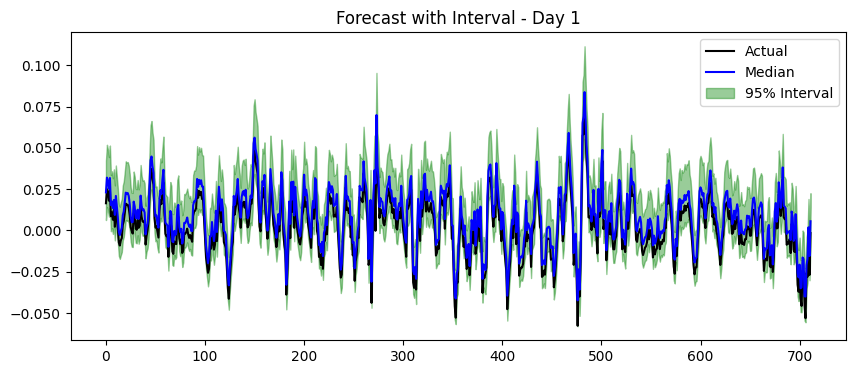

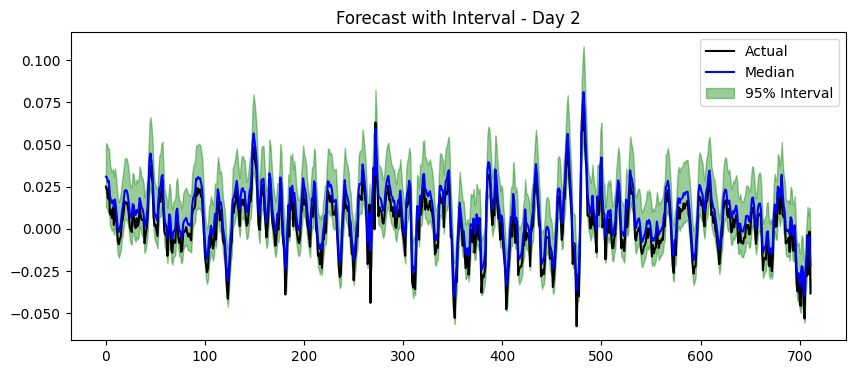

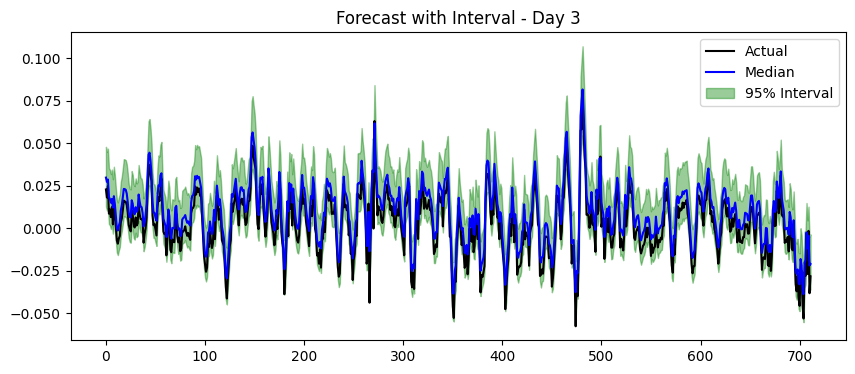

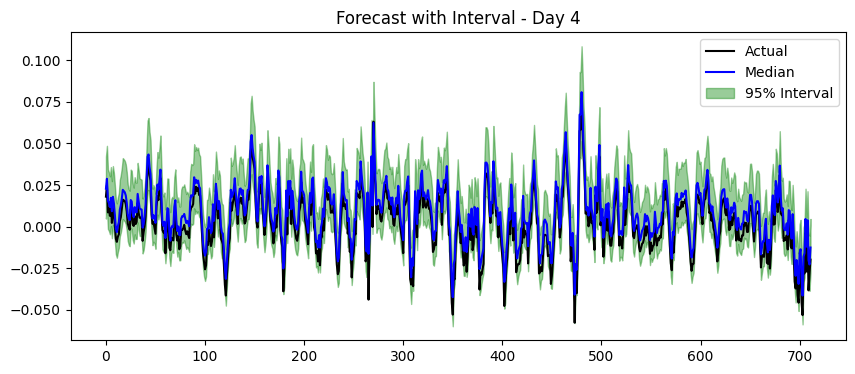

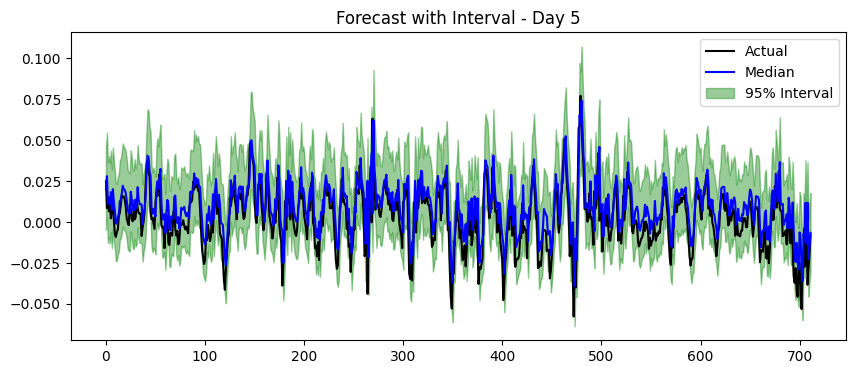

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score

from tensorflow.keras.layers import (
    Input, Dense, MultiHeadAttention,
    LayerNormalization, Dropout
)
from tensorflow.keras.models import Model


# -------------------------------
# 🔹 Load Data
# -------------------------------
df = pd.read_csv("data/nifty50_with_sector_returns_yfinance1.csv")

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')
df.set_index('date', inplace=True)

df = df.ffill().bfill()

df['return'] = df['close'].pct_change(5)
df = df.dropna()


# -------------------------------
# 🔹 Prepare Data
# -------------------------------
features = df.columns.tolist()
features.remove('return')

X = df[features]
y = df['return']

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1,1))


# -------------------------------
# 🔹 Sequence Creation
# -------------------------------
def create_seq2seq(X, y, n_steps=20, horizon=5):
    Xs, ys = [], []
    for i in range(len(X) - n_steps - horizon):
        Xs.append(X[i:i+n_steps])
        ys.append(y[i+n_steps:i+n_steps+horizon])
    return np.array(Xs), np.array(ys)

n_steps = 20
horizon = 5

X_seq, y_seq = create_seq2seq(X_scaled, y_scaled, n_steps, horizon)

split = int(0.8 * len(X_seq))
X_train, X_test = X_seq[:split], X_seq[split:]
y_train, y_test = y_seq[:split], y_seq[split:]


# -------------------------------
# 🔹 Quantile Loss
# -------------------------------
quantiles = [0.05, 0.5, 0.95]

def quantile_loss(qs):
    def loss(y_true, y_pred):
        losses = []
        for i, q in enumerate(qs):
            e = y_true - y_pred[:, :, i:i+1]
            losses.append(tf.reduce_mean(tf.maximum(q*e, (q-1)*e)))
        return tf.reduce_mean(tf.stack(losses, axis=-1))
    return loss


# -------------------------------
# 🔹 Positional Encoding
# -------------------------------
def positional_encoding(seq_len, d_model):
    pos = np.arange(seq_len)[:, np.newaxis]
    i = np.arange(d_model)[np.newaxis, :]
    
    angle_rates = 1 / np.power(10000, (2*(i//2))/d_model)
    angle_rads = pos * angle_rates
    
    pe = np.zeros((seq_len, d_model))
    pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
    pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
    
    return tf.cast(pe, dtype=tf.float32)


# -------------------------------
# 🔹 Transformer Blocks
# -------------------------------
def encoder_block(x, head_size, num_heads, ff_dim, dropout=0.1):
    attn = MultiHeadAttention(num_heads=num_heads, key_dim=head_size)(x, x)
    x = LayerNormalization()(x + attn)
    
    ff = Dense(ff_dim, activation="gelu")(x)
    ff = Dense(x.shape[-1])(ff)
    x = LayerNormalization()(x + ff)
    
    return Dropout(dropout)(x)


def decoder_block(x, enc_out, head_size, num_heads, ff_dim, dropout=0.1):
    attn1 = MultiHeadAttention(num_heads=num_heads, key_dim=head_size)(x, x)
    x = LayerNormalization()(x + attn1)
    
    attn2 = MultiHeadAttention(num_heads=num_heads, key_dim=head_size)(x, enc_out)
    x = LayerNormalization()(x + attn2)
    
    ff = Dense(ff_dim, activation="gelu")(x)
    ff = Dense(x.shape[-1])(ff)
    x = LayerNormalization()(x + ff)
    
    return Dropout(dropout)(x)


# -------------------------------
# 🔹 Build Model (Quantile Output)
# -------------------------------
def build_model(n_steps, n_features, horizon, d_model=64):

    enc_inputs = Input(shape=(n_steps, n_features))
    x = Dense(d_model)(enc_inputs)
    x = x + positional_encoding(n_steps, d_model)

    for _ in range(2):
        x = encoder_block(x, d_model//4, 4, d_model*2)

    enc_out = x

    dec_inputs = Input(shape=(horizon, 1))
    y = Dense(d_model)(dec_inputs)
    y = y + positional_encoding(horizon, d_model)

    for _ in range(2):
        y = decoder_block(y, enc_out, d_model//4, 4, d_model*2)

    # 🔥 Output 3 quantiles
    outputs = Dense(len(quantiles))(y)

    model = Model([enc_inputs, dec_inputs], outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(0.001),
        loss=quantile_loss(quantiles)
    )

    return model


# -------------------------------
# 🔹 Decoder Input
# -------------------------------
def create_decoder_input(y):
    dec = np.zeros_like(y)
    dec[:, 1:] = y[:, :-1]
    return dec

decoder_train = create_decoder_input(y_train)
decoder_test = create_decoder_input(y_test)


# -------------------------------
# 🔹 Train
# -------------------------------
model = build_model(n_steps, X_train.shape[2], horizon)

model.fit(
    [X_train, decoder_train],
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2
)


# -------------------------------
# 🔹 Prediction
# -------------------------------
y_pred = model.predict([X_test, decoder_test])


# -------------------------------
# 🔹 Extract Quantiles
# -------------------------------
lower = y_pred[:, :, 0]
median = y_pred[:, :, 1]
upper = y_pred[:, :, 2]

# Inverse scaling
y_test_inv = scaler_y.inverse_transform(y_test.reshape(-1,1)).reshape(y_test.shape)
median_inv = scaler_y.inverse_transform(median.reshape(-1,1)).reshape(median.shape)
lower_inv = scaler_y.inverse_transform(lower.reshape(-1,1)).reshape(lower.shape)
upper_inv = scaler_y.inverse_transform(upper.reshape(-1,1)).reshape(upper.shape)


# -------------------------------
# 🔹 Evaluation (on median)
# -------------------------------
mse = mean_squared_error(y_test_inv.flatten(), median_inv.flatten())
rmse = np.sqrt(mse)
r2 = r2_score(y_test_inv.flatten(), median_inv.flatten())

print("MSE :", mse)
print("RMSE:", rmse)
print("R2  :", r2)


# -------------------------------
# 🔹 Visualization (Intervals)
# -------------------------------
for i in range(horizon):
    plt.figure(figsize=(10,4))
    
    plt.plot(y_test_inv[:, i], label="Actual", color="black")
    plt.plot(median_inv[:, i], label="Median", color="blue")
    
    plt.fill_between(
        range(len(lower_inv)),
        lower_inv[:, i],
        upper_inv[:, i],
        color="green",
        alpha=0.4,
        label="95% Interval"
    )
    
    plt.title(f"Forecast with Interval - Day {i+1}")
    plt.legend()
    plt.show()